In [2]:
import json, pandas as pd, numpy as np, matplotlib.pyplot as plt

In [18]:
from pathlib import Path
DATA = Path("..") / "data"      # notebook is in python/, data is one level up

books  = [json.loads(l) for l in open(DATA / "book.jsonl")]
rows = []

In [ ]:
for b in books:
    bid, ask = b["bids"][0][0], b["asks"][0][0]
    rows.append({"ts": b["ts"], "mid": (bid+ask)/2, "spread": ask-bid,
                 "bid_depth": sum(level[1] for level in b["bids"]),
                 "ask_depth": sum(level[1] for level in b["asks"])})
df = pd.DataFrame(rows); df["time"] = pd.to_datetime(df["ts"], unit="ms")
df = df.sort_values("ts").reset_index(drop=True)

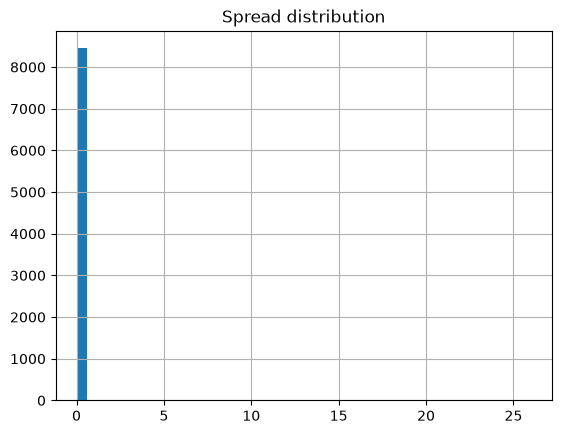

count    8505.000000
mean        0.191640
std         1.349254
min         0.100000
25%         0.100000
50%         0.100000
75%         0.100000
max        25.900000
Name: spread, dtype: float64


In [24]:
df["spread"].hist(bins=50); plt.title("Spread distribution"); plt.show()
print(df["spread"].describe())

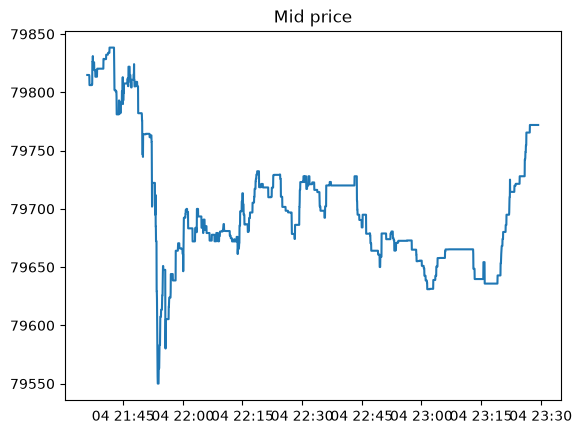

fraction of snapshots where mid changed: 0.035861258083480306


In [25]:
plt.plot(df["time"], df["mid"]); plt.title("Mid price"); plt.show()
print("fraction of snapshots where mid changed:", (df["mid"].diff() != 0).mean())


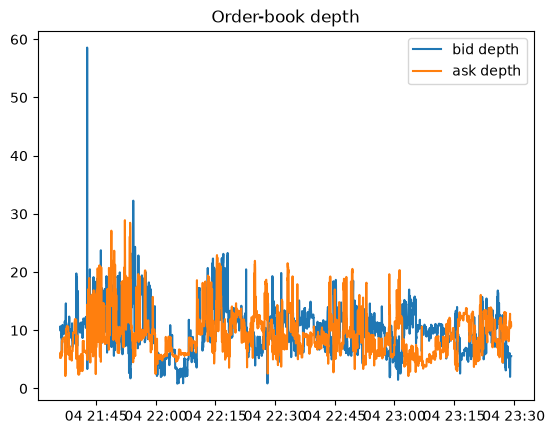

In [26]:
plt.plot(df["time"], df["bid_depth"], label="bid depth")
plt.plot(df["time"], df["ask_depth"], label="ask depth")
plt.legend(); plt.title("Order-book depth"); plt.show()

In [29]:
trades = [json.loads(l) for l in open("../data/trades.jsonl")]
td = pd.DataFrame(trades)
duration_s = (td["ts"].max() - td["ts"].min()) / 1000
print(f"trade arrival rate ~= {len(td)/duration_s:.3f} per second")
print(td["side"].value_counts())

trade arrival rate ~= 0.682 per second
side
buy     2869
sell    1803
Name: count, dtype: int64


In [ ]:
'''
~ 90 min of data collected
spread = 0.100000
mid-volatility = 0.035861258083480306
arrival rate = 0.682/sec
'''